In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pairs_trading.data.loaders import load_prices
from pairs_trading.config import SplitConfig, KalmanConfig
from pairs_trading.models.ols_hedge import OLSHedge
from pairs_trading.models.kalman_hedge import KalmanHedge
from pairs_trading.signals.zscore import rolling_zscore, generate_signal
from pairs_trading.backtest.engine import BacktestEngine

First let's build a dataframe containing all the tickers that we want to test. Split between train and test sets.

In [5]:
tickers = ["IAU", "GDX", "GLD", "SLV", "OIH", "XLE", "REM", "VNQ"]
df_train = load_prices(tickers, SplitConfig.train_start, SplitConfig.train_end, refresh=True)
df_test = load_prices(tickers, SplitConfig.test_start, SplitConfig.test_end, refresh=True)

[*********************100%***********************]  8 of 8 completed
[*********************100%***********************]  8 of 8 completed


Run the training-testing pipeline on all 4 pairs and return the resulting metrics

In [6]:
pairs = [["IAU", "GDX"],["GLD", "SLV"], ["OIH", "XLE"], ["REM", "VNQ"]]

First let's compute the dynamic beta and compare it to the static one

beta at day 150: 0.3831, alpha at day 150: 23.4709
OLS beta: 0.3577, OLS alpha: 23.1241
beta at day 150: 3.4221, alpha at day 150: 103.9160
OLS beta: 2.1109, OLS alpha: 123.6338
beta at day 150: 11.2788, alpha at day 150: -43.3199
OLS beta: 6.3656, OLS alpha: 34.8239
beta at day 150: 0.3020, alpha at day 150: -3.6629
OLS beta: 0.2807, OLS alpha: -1.4468


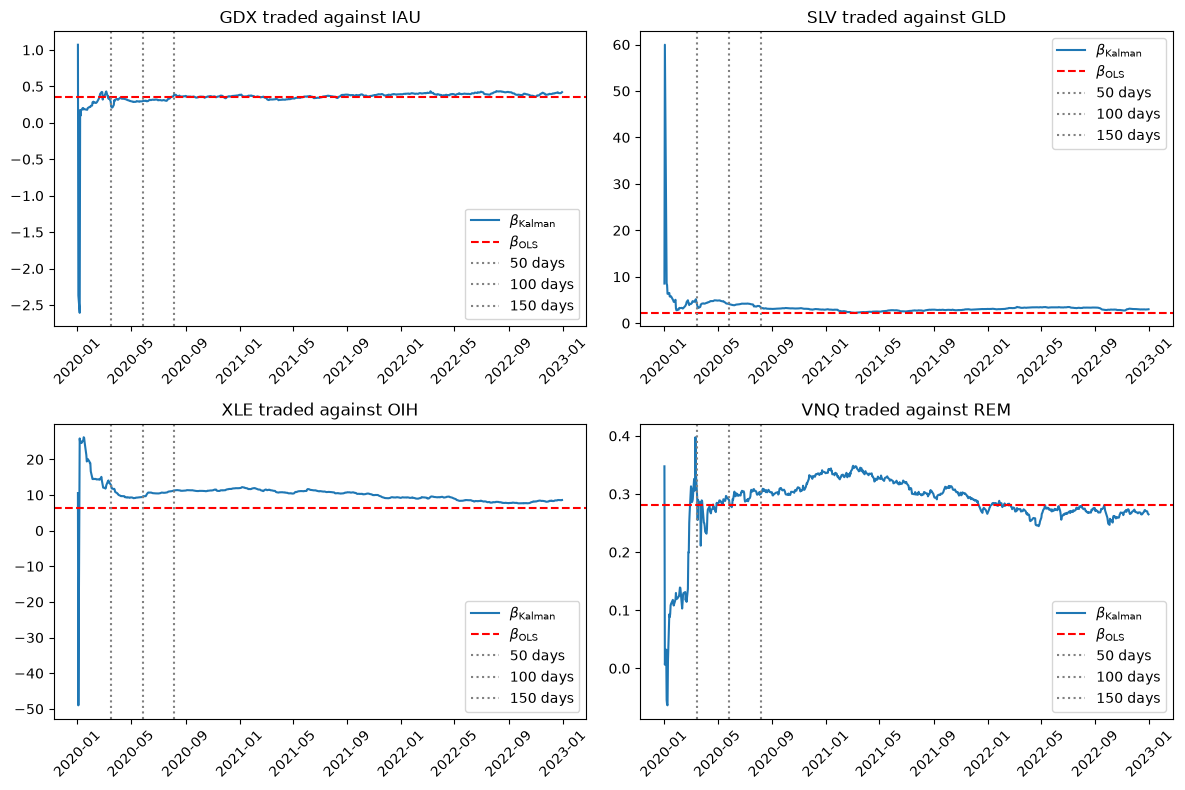

In [29]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12,8))
axs = axs.flatten()
for i, (y, x) in enumerate(pairs):
    hedge_ols = OLSHedge()
    hedge_ols.fit(df_train[y], df_train[x])
    config = KalmanConfig(delta=1e-6)
    hedge_kalman = KalmanHedge(config=config)
    hedge_kalman.fit(df_train[y], df_train[x])
    print(f"beta at day 150: {hedge_kalman.beta.iloc[150]:.4f}, alpha at day 150: {hedge_kalman.alpha.iloc[150]:.4f}")
    print(f"OLS beta: {hedge_ols.beta:.4f}, OLS alpha: {hedge_ols.alpha:.4f}")

    axs[i].plot(hedge_kalman.beta, label=r"$\beta_\mathrm{Kalman}$")
    axs[i].axhline(y=hedge_ols.beta, color='r', linestyle='--', label=r"$\beta_\mathrm{OLS}$")
    axs[i].axvline(x=df_train.index[50], color='gray', linestyle=':', label='50 days')
    axs[i].axvline(x=df_train.index[100], color='gray', linestyle=':', label='100 days')
    axs[i].axvline(x=df_train.index[150], color='gray', linestyle=':', label='150 days')
    
    axs[i].legend()
    axs[i].set_title(f"{x} traded against {y}")
for ax in axs:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Next lets tune delta on the train set:

In [48]:
delta_values = np.logspace(-6, -2, 5)
rows = []
for delta in delta_values:
    for y, x in pairs:
        ols = OLSHedge()
        ols.fit(df_train[y], df_train[x])
        res_ols = ols.spread(df_train[y], df_train[x])
        config = KalmanConfig(delta=delta, obs_noise=res_ols.var())
        
        hedge_kalman = KalmanHedge(config=config)
        hedge_kalman.fit(df_train[y], df_train[x])
        residuals_kalman = hedge_kalman.residuals.iloc[150:]
        zscores_kalman = rolling_zscore(residuals_kalman)
        signals_kalman = generate_signal(zscores_kalman)
        hedge_kalman_ratios = hedge_kalman.beta.iloc[150:]
        engine_kalman = BacktestEngine()
        result_kalman = engine_kalman.run(df_train[y].iloc[150:], df_train[x].iloc[150:], signals_kalman, hedge_kalman_ratios)
        rows.append({"delta": f"{delta:.0e}", "pair": f"{x}/{y}", **result_kalman.metrics})

df_results = pd.DataFrame(rows).set_index(["pair", "delta"])
df_results.round(3)

,,sharpe,max_drawdown,hit_rate,average_holding_period,n_trades
pair,delta,,,,,
GDX/IAU,1e-06,-1.109,0.139,0.482,12.250,13
SLV/GLD,1e-06,-0.878,0.892,0.461,20.600,10
XLE/OIH,1e-06,-0.985,5.125,0.435,18.286,14
VNQ/REM,1e-06,0.587,0.140,0.495,14.250,12
GDX/IAU,1e-05,-1.222,0.131,0.406,8.091,11
SLV/GLD,1e-05,-0.848,0.934,0.456,19.500,10
XLE/OIH,1e-05,-1.028,5.352,0.435,18.143,14
VNQ/REM,1e-05,-0.573,0.248,0.458,9.133,15
GDX/IAU,1e-04,-1.927,0.187,0.329,4.600,15


We pick the delta values with the best Sharpe ratios in the comparison with the OLS approach

Final test results for trading GDX against IAU:
OLS sharpe: -0.3169531427421496
Kalman sharpe: -0.3291410199978723
OLS max_drawdown: 0.047997001281951626
Kalman max_drawdown: 0.03627306623518224
OLS hit_rate: 0.4424778761061947
Kalman hit_rate: 0.46875
OLS average_holding_period: 10.555555555555555
Kalman average_holding_period: 10.0
OLS n_trades: 10
Kalman n_trades: 6
----------------------------------------


Final test results for trading SLV against GLD:
OLS sharpe: -0.7769101927006595
Kalman sharpe: 1.3719630184861173
OLS max_drawdown: 0.5137730395737883
Kalman max_drawdown: 0.10961230996158694
OLS hit_rate: 0.44696969696969696
Kalman hit_rate: 0.47058823529411764
OLS average_holding_period: 17.714285714285715
Kalman average_holding_period: 7.416666666666667
OLS n_trades: 7
Kalman n_trades: 12
----------------------------------------


Final test results for trading XLE against OIH:
OLS sharpe: -0.07544792135377028
Kalman sharpe: -0.18782252654335246
OLS max_drawdown: 1.2288293017

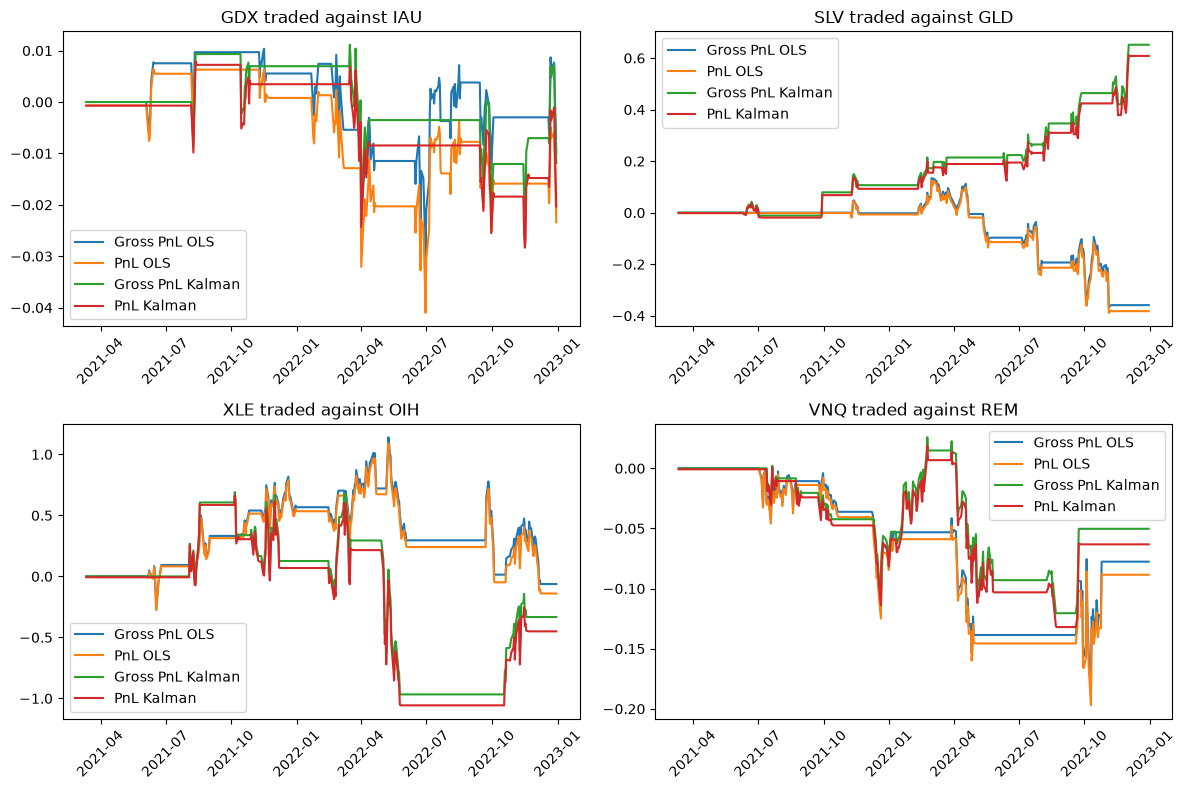

In [50]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12,8))
axs = axs.flatten()
deltas = [1e-6, 1e-3, 1e-3, 1e-6]
for i, (y, x) in enumerate(pairs):
    hedge_ols = OLSHedge()
    hedge_ols.fit(df_train[y], df_train[x])
    residuals_ols = hedge_ols.spread(df_train.iloc[300:][y], df_train.iloc[300:][x])
    zscores_ols = rolling_zscore(residuals_ols)
    signals_ols = generate_signal(zscores_ols)
    hedge_ols_ratios = pd.Series(hedge_ols.beta, index=signals_ols.index)
    engine_ols = BacktestEngine()
    result_ols = engine_ols.run(df_train.iloc[300:][y], df_train.iloc[300:][x], signals_ols, hedge_ols_ratios)


    config = KalmanConfig(delta=deltas[i], obs_noise = residuals_ols.var())
    hedge_kalman = KalmanHedge(config=config)
    hedge_kalman.fit(df_train[y], df_train[x])
    residuals_kalman = hedge_kalman.residuals.iloc[300:]
    zscores_kalman = rolling_zscore(residuals_kalman)
    signals_kalman = generate_signal(zscores_kalman)
    hedge_kalman_ratios = pd.Series(hedge_kalman.beta, index=signals_kalman.index)
    engine_kalman = BacktestEngine()
    result_kalman = engine_kalman.run(df_train.iloc[300:][y], df_train.iloc[300:][x], signals_kalman, hedge_kalman_ratios)
    print(f"Final test results for trading {x} against {y}:")
    for key in result_ols.metrics.keys():
        print(f"OLS {key}: {result_ols.metrics[key]}")
        print(f"Kalman {key}: {result_kalman.metrics[key]}")

    print("-"*40)
    print("\n")
    axs[i].plot(result_ols.gross_pnl.cumsum(), label="Gross PnL OLS")
    axs[i].plot(result_ols.pnl.cumsum(), label="PnL OLS")
    axs[i].plot(result_kalman.gross_pnl.cumsum(), label="Gross PnL Kalman")
    axs[i].plot(result_kalman.pnl.cumsum(), label="PnL Kalman")
    axs[i].legend()
    axs[i].set_title(f"{x} traded against {y}")
for ax in axs:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

OLS outperforms Kalman for GDX vs IAU and for VNQ against REM. But for both of these the Sharpe is negative in any case. For the other two pairs Kalman outperforms OLS. However the hit rate is still around 50\% and thus we cannot exclude random chance we will see more once we use the test set.